# Sesi 10 - Object Detection

- [] Face Detection
- [] Face Recognition


In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
# Load pre-trained model dari haarcascade untuk deteksi wajah
face_cascade = cv2.CascadeClassifier('dataset_PT10/haarcascade_frontalface_default.xml')

face_list = []
class_list = []

train_path = 'dataset_PT10/train'
test_path = 'dataset_PT10/test'
person_name = os.listdir(train_path)
print('Person Name: ', person_name)

Person Name:  ['Mulyono', 'CEO MBG', 'Mas Bahlil Gntg']


In [3]:
# training dataset pake haarcascade
for idx, name in enumerate(person_name):
    full_path = os.path.join(train_path, name)

    for img_name in os.listdir(full_path):
        img_full_path = os.path.join(full_path, img_name)
        img = cv2.imread(img_full_path, cv2.IMREAD_GRAYSCALE)

        # use pretrained model to detect face
        # img, scaleFactor, minNeighbors
        detected_face = face_cascade.detectMultiScale(img, scaleFactor=1.2, minNeighbors=5)

        # validate face not dtect
        if len(detected_face) < 1:
            print('No face detected in image: ', img_full_path)
            continue

        for face_rect in detected_face:
            x, y, w, h = face_rect
            face_img = img[y:y+h, x:x+w]
            face_list.append(face_img)
            class_list.append(idx)

In [4]:
# face recognition pake LBPH -> feed pake cropped image face_list
face_recognizer = cv2.face.LBPHFaceRecognizer_create()
face_recognizer.train(face_list, np.array(class_list))

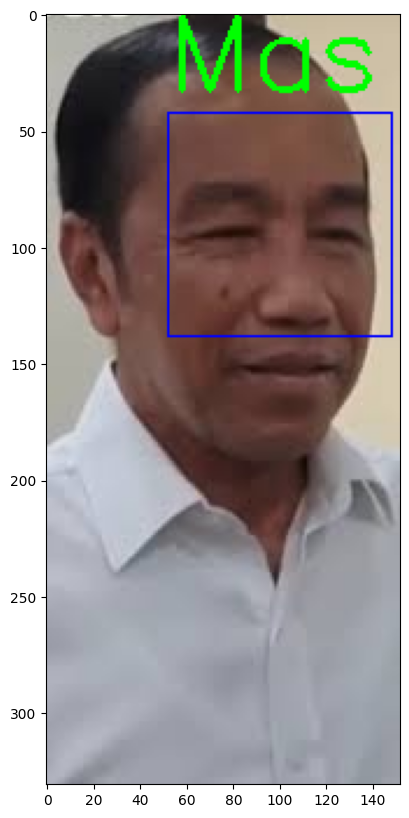

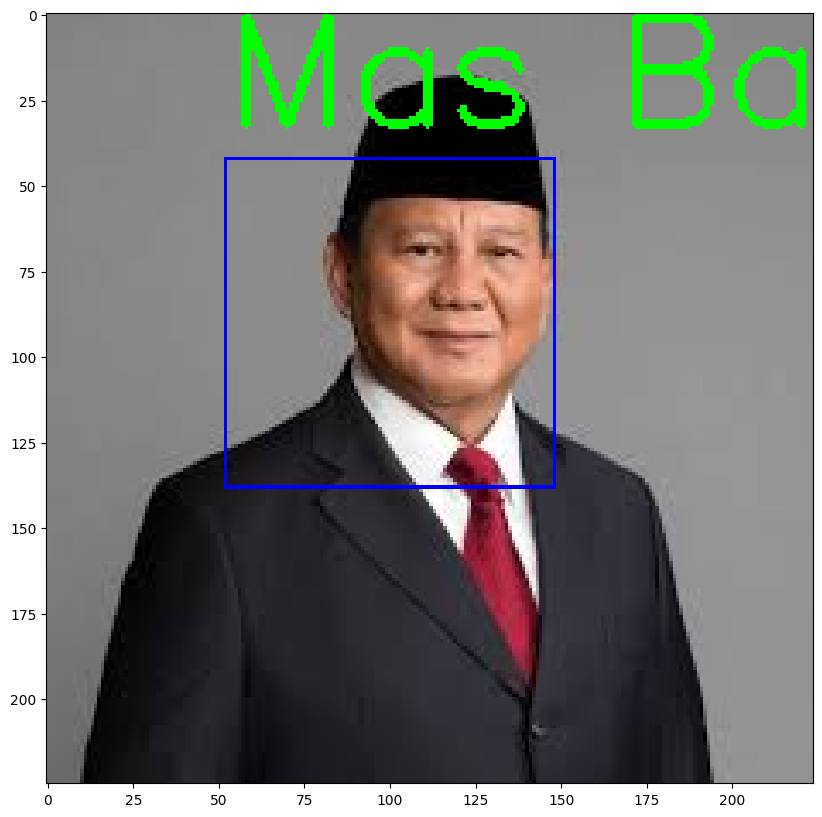

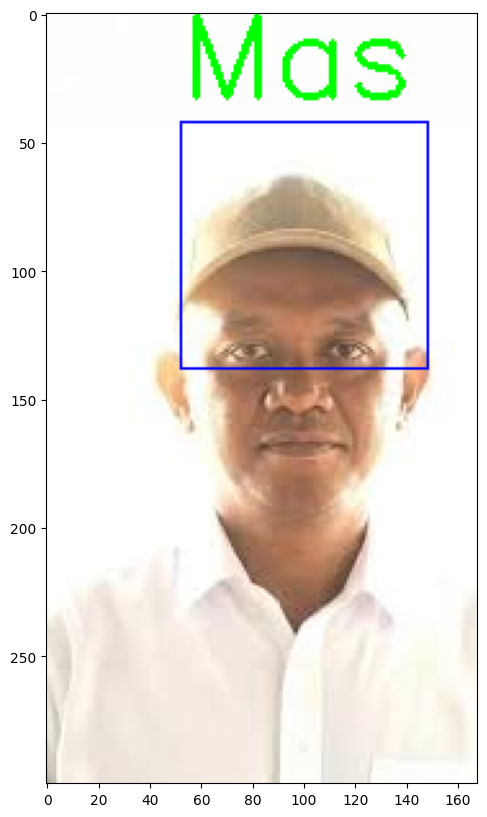

In [8]:
# TESTING
for img_name in os.listdir(test_path):
    img_full_path = os.path.join(test_path, img_name)
    img_gray = cv2.imread(img_full_path, cv2.IMREAD_GRAYSCALE)
    img_bgr = cv2.imread(img_full_path)

    detected_face = face_cascade.detectMultiScale(img, scaleFactor=1.2, minNeighbors=5)

    if len(detected_face) < 1:
        print('No face detected in image: ', img_full_path)
        continue

    for face_rect in detected_face:
        x, y, w, h = face_rect
        face_img = img[y:y+h, x:x+w]

        res, confidence = face_recognizer.predict(face_img)

        # bikin small rectangle buat ditampilin di gambarnya
        cv2.rectangle(img_bgr, (x, y), (x+w, y+h), (255, 0, 0), thickness=1)
        text = person_name[res] + ' : ' + str(confidence)
        cv2.putText(img_bgr, text, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), thickness=2)

        # show di matplotlib
        plt.figure(figsize=(100, 10))
        plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        plt.show()
        